In [41]:
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.stats as sts

In [2]:
def relations(n, edges):
    rel = [set() for _ in range(n)]
    for u, v in edges:
        u0, v0 = u - 1, v - 1
        rel[u0].add(v0)
        rel[v0].add(u0)
    return rel

def initial(rel): # построение независимого множества для начальной границы
    n = len(rel)
    used = [False] * n
    selected = []
    # идем по вершинам в порядке возрастания степени
    for v in sorted(range(n), key=lambda x: len(rel[x])):
        if not used[v]:
            selected.append(v)
            used[v] = True
            for u in rel[v]:
                used[u] = True
    return selected

def max_independent_set_opt(rel):
    n = len(rel)
    best = initial(rel)          # хорошая начальная граница
    candidates = set(range(n))

    def backtrack(cand, current):
        nonlocal best
        # Отсечение: даже если взять все оставшиеся, не превзойдём лучшее
        if len(current) + len(cand) <= len(best):
            return
        if not cand:
            if len(current) > len(best):
                best = current[:]
            return
        # Выбираем вершину с максимальной степенью среди кандидатов
        v = max(cand, key=lambda x: len(rel[x] & cand))
        # Ветвь 1: включаем v
        backtrack(cand - {v} - (rel[v] & cand), current + [v])
        # Ветвь 2: не включаем v
        backtrack(cand - {v}, current)

    backtrack(candidates, [])
    return best

In [ ]:
edges = [(1,2), (1,3), (2,3), (2,4), (2,5), (3,6), (3,7), (4,7), (5,7), (6,7)]
n = 7
rel = relations(n, edges)
result = max_independent_set_opt(rel)
print("Максимальное независимое множество (в 1-индексации):", [v+1 for v in result])
print("Размер:", len(result))

Максимальное независимое множество (в 1-индексации): [1, 4, 5, 6]
Размер: 4


In [ ]:
%timeit max_independent_set_opt(rel)

26.8 µs ± 1.34 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
# пример с графом малого мира
G = nx.watts_strogatz_graph(n = 15, k = 4, p = 0.3, seed=42)
edges_nx = list(G.edges())
edges1 = [(u+1, v+1) for u, v in edges_nx]
n = 15

In [ ]:
rel1 = relations(n, edges1)
result1 = max_independent_set_opt(rel1)
print(edges1)
print("Максимальное независимое множество (в 1-индексации):", [v+1 for v in result1])
print("Размер:", len(result1))

[(1, 2), (1, 15), (1, 3), (1, 14), (1, 6), (1, 8), (1, 7), (2, 15), (2, 5), (2, 13), (2, 4), (3, 5), (3, 12), (3, 14), (4, 12), (4, 7), (5, 6), (5, 7), (6, 8), (8, 10), (9, 10), (9, 11), (10, 11), (10, 12), (11, 12), (11, 13), (12, 13), (12, 14), (13, 14), (13, 15)]
Максимальное независимое множество (в 1-индексации): [5, 9, 4, 14, 15, 8]
Размер: 6


In [ ]:
%timeit max_independent_set_opt(rel1)

451 µs ± 203 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [4]:
# генератор графов
def generate_gnp_graph(n, p):
    G = nx.erdos_renyi_graph(n, p)
    edges = [(u+1, v+1) for u, v in G.edges()]
    return edges

# функция для однократного измерения
def measure_time(n, p=0.5):
    edges = generate_gnp_graph(n, p)
    rel = relations(n, edges)
    start = time.perf_counter()
    max_independent_set_opt(rel)
    end = time.perf_counter()
    return end - start

In [6]:
# эксперимент на графах (от 10 до 50 вершин)
p_edge = 0.5
n_min, n_max = 10, 50
n_values = list(range(n_min, n_max + 1))
trials_per_n = 50

mean_times = []
std_times = []

for n in n_values:
    times = []
    for _ in range(trials_per_n):
        t = measure_time(n, p_edge)
        times.append(t)
    mean_times.append(np.mean(times))
    std_times.append(np.std(times, ddof=1))

mean_times = np.array(mean_times)
std_times = np.array(std_times)

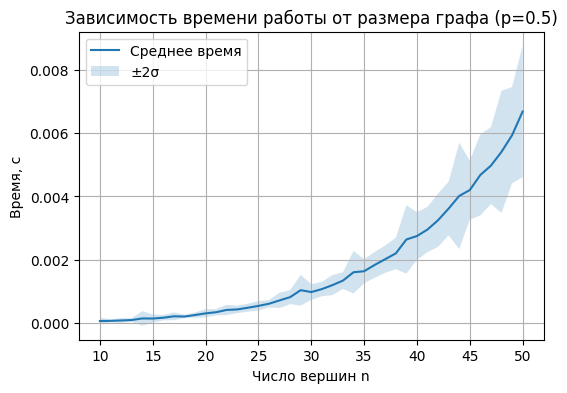

In [ ]:
# График зависимости времени от n
plt.figure(figsize=(6,4))
plt.plot(n_values, mean_times, '-', label='Среднее время')
plt.fill_between(n_values, mean_times - 2*std_times, mean_times + 2*std_times,
                 alpha=0.2, label='±2σ')
plt.xlabel('Число вершин n')
plt.ylabel('Время, с')
plt.title('Зависимость времени работы от размера графа (p=0.5)')
plt.legend()
plt.grid();


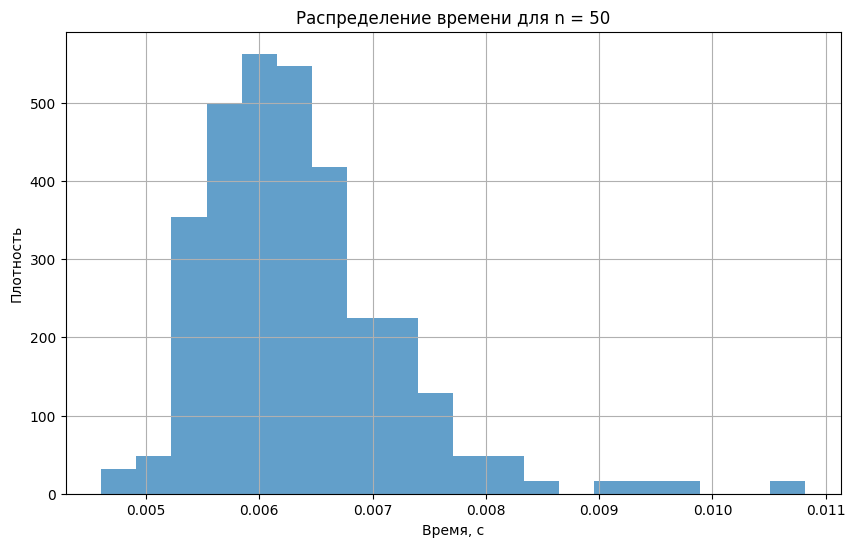

In [26]:
n_fixed = 50
trials_hist = 200
times_fixed = [measure_time(n_fixed, p_edge) for _ in range(trials_hist)]

plt.figure(figsize=(10, 6))
plt.hist(times_fixed, bins=20, density=True, alpha=0.7, label='Эмпирическая плотность')
plt.xlabel('Время, с')
plt.ylabel('Плотность')
plt.title(f'Распределение времени для n = {n_fixed}')
plt.grid(True)

In [56]:
# Проверяем гипотезу о нормальности распределения (критерий Шапиро-Уилка)
# для n=50
stat, p_value = sts.shapiro(times_fixed)

print(f"Статистика Шапиро–Уилка: {stat}")
print(f"p-value: {p_value}")

alpha = 0.05
if p_value > alpha:
    print("Нет оснований отвергнуть гипотезу о нормальности")
else:
    print("Гипотеза о нормальности отвергается")

Статистика Шапиро–Уилка: 0.9034385888331372
p-value: 4.183907881354478e-10
Гипотеза о нормальности отвергается


In [57]:
# Критерий Колмогорова-Смирнова (n = 50)
times_fixed = np.array(times_fixed)

# Экспоненциальное распределение
scale_exp = np.mean(times_fixed)
ks_exp, p_exp = sts.kstest(times_fixed, 'expon', args=(0, scale_exp))
print(f"KS тест для экспоненциального распределения: статистика = {ks_exp}, p-value = {p_exp}")
if p_exp > ks_exp:
    print("Нет оснований отвергнуть гипотезу об экспоненциальном распредлении")
else:
    print("Гипотеза об экспоненциальном распредлении отвергается")

# Логнормальное распределение
shape, loc, scale_logn = sts.lognorm.fit(times_fixed, floc=0)
ks_logn, p_logn = sts.kstest(times_fixed, 'lognorm', args=(shape, loc, scale_logn))
print(f"\nKS тест для логнормального распределения: статистика = {ks_logn}, p-value = {p_logn}")
if p_logn > ks_logn:
    print("Нет оснований отвергнуть гипотезу о логнормальном распредлении")
else:
    print("Гипотеза о логнормальном распределении отвергается")

KS тест для экспоненциального распределения: статистика = 0.5482887191930144, p-value = 5.882665617726139e-57
Гипотеза об экспоненциальном распредлении отвергается

KS тест для логнормального распределения: статистика = 0.07538500577419649, p-value = 0.19561905991152162
Нет оснований отвергнуть гипотезу о логнормальном распредлении
